# Подбор метода уровней и ATR-множителей (буфер / SL / трейлинг) для стратегии отскока

Стратегия bounce: лимитные ордера ставятся **перед** уровнем
- `Buy Limit = S + buffer_atr_s * ATR` (лонг от поддержки S)
- `Sell Limit = R - buffer_atr_r * ATR` (шорт от сопротивления R)

Оптимизируется: метод уровней (Camarilla / Pivot / DeMark) и **шесть** множителей ATR —
буфер, SL и трейлинг **отдельно** для лонга (S) и шорта (R).

**Данные**: положите `EURUSD_H1_2020-01-01_2025-12-31.csv` в папку `content/`
рядом с ноутбуком (локально) или загрузите его в `/content/` в Colab.
Пути подхватятся автоматически.

Запускайте ячейки сверху вниз. Полный подбор занимает ~20 минут
(480 комбинаций на 2020–2024 + проверка на 2025).


In [5]:
# В Colab backtesting обычно уже стоит, но подстрахуемся
try:
    import backtesting
    print("backtesting уже установлен:", backtesting.__version__)
    import matplotlib.pyplot as plt
    print("matplotlib уже установлен:")

except ImportError:
    get_ipython().system('pip install -q backtesting')
    import backtesting
    print("backtesting установлен:", backtesting.__version__)
    get_ipython().system('pip install -q matplotlib')
    import matplotlib.pyplot as plt
    print("matplotlib установлен:")


backtesting уже установлен: 0.6.6
matplotlib уже установлен:


In [6]:
import os
import warnings
from itertools import product

import numpy as np
import pandas as pd

from backtesting import Backtest, Strategy

# import backtesting.backtesting as _bb # Отключаем tqdm-прогресс каждого прогона — при 480+ запусках он забивает лог
# _bb._tqdm = lambda iterable, **kwargs: iterable
# Штатное предупреждение backtesting.py про SL/TP в том же баре, что и вход
warnings.filterwarnings(
    "ignore",
    message=".*contingent SL/TP order would execute in the same bar.*",
)

CONFIG = {
    "data_file": "EURUSD_H1_2020-01-01_2025-12-31.csv",
    "atr_period": 14,
    # Сдвиг начала суток для расчёта дневных уровней.
    # 0 = полночь UTC по времени баров. Если уровни в MT5 считаются
    # по серверным суткам (обычно UTC+2/+3), задайте 2 или 3.
    "day_offset_hours": 0,
    "split_date": "2025-01-01",   # подбор до этой даты, проверка с неё
    "cash": 100_000,
    "leverage": 100,                # кредитное плечо счета 1:100
    "commission": 0.00002,        # ~0.002% (реалистично для 0.01 лота EURUSD)
    "min_trades": 30,             # минимум сделок для отсева дегенерата
    "top_n": 10,                  # сколько комбинаций показывать в топе
    "max_risk_per_trade_pct": 0.02, # Максимальный риск на сделку в % от эквити
    "max_margin_failures": 3,     # остановка подбора после отказов по марже
}

# Сетки множителей (одинаковые для S и R)
BUFFER_GRID = [0.05, 0.1, 0.15, 0.2, 0.25]
SL_GRID     = [0.5,1.0, 1.5, 2.0, 2.5, 3.0]
TP_GRID     = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0] # Новая сетка для Take Profit

LEVEL_METHOD_NAMES = {0: "Camarilla", 1: "Pivot (классика)", 2: "DeMark"}

# Поддержки/сопротивления по методам (колонки, создаваемые в prepare)
SUP_COLS = {
    0: ["cam_s1", "cam_s2", "cam_s3", "cam_s4"],
    1: ["piv_s1", "piv_s2", "piv_s3"],
    2: ["dem_s1"],
}
RES_COLS = {
    0: ["cam_r1", "cam_r2", "cam_r3", "cam_r4"],
    1: ["piv_r1", "piv_r2", "piv_r3"],
    2: ["dem_r1"],
}

# --- путь к данным: пробуем варианты (Colab: /content/, локально: content/) ---
_CANDIDATE_PATHS = [
    "content/EURUSD_H1_2020-01-01_2025-12-31.csv",          # локально, папка content/
    "/content/EURUSD_H1_2020-01-01_2025-12-31.csv",         # Colab: файл в /content/
    "/content/content/EURUSD_H1_2020-01-01_2025-12-31.csv", # Colab: папка content/ внутри /content/
    "EURUSD_H1_2020-01-01_2025-12-31.csv",                  # текущая папка
]
DATA_PATH = next((p for p in _CANDIDATE_PATHS if os.path.exists(p)), None)
if DATA_PATH is None:
    try:
        from google.colab import files  # только в Colab
        print("CSV не найден. Загрузите файл",
              CONFIG["data_file"], "в /content/ ...")
        uploaded = files.upload()
        DATA_PATH = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError(
            f"Положите {CONFIG['data_file']} в папку content/ рядом с ноутбуком"
        )
print("Данные:", DATA_PATH)

Данные: content/EURUSD_H1_2020-01-01_2025-12-31.csv


In [7]:
# ---------- Уровни (формулы как в индикаторах MT5) ----------

def camarilla_levels(d1):
    """Camarilla: R1-R4 / S1-S4, коэф. 1.1/12, /6, /4, /2."""
    h, l, c = d1["High"], d1["Low"], d1["Close"]
    hl = h - l
    out = pd.DataFrame(index=d1.index)
    for i, div in enumerate([12, 6, 4, 2], start=1):
        out[f"cam_r{i}"] = c + hl * 1.1 / div
        out[f"cam_s{i}"] = c - hl * 1.1 / div
    return out


def pivot_levels(d1):
    """Классические Pivot: P, R1-R3 / S1-S3."""
    h, l, c = d1["High"], d1["Low"], d1["Close"]
    p = (h + l + c) / 3
    out = pd.DataFrame(index=d1.index)
    out["piv_r1"] = 2 * p - l
    out["piv_s1"] = 2 * p - h
    out["piv_r2"] = p + (h - l)
    out["piv_s2"] = p - (h - l)
    out["piv_r3"] = h + 2 * (p - l)
    out["piv_s3"] = l - 2 * (h - p)
    return out


def demark_levels(d1):
    """DeMark: P, R1 / S1 (X зависит от close vs open)."""
    h, l, c, o = d1["High"], d1["Low"], d1["Close"], d1["Open"]
    x = pd.Series(
        np.where(c < o, h + 2 * l + c,
                 np.where(c > o, 2 * h + l + c, h + l + 2 * c)),
        index=d1.index,
    )
    out = pd.DataFrame(index=d1.index)
    out["dem_r1"] = x / 2 - l
    out["dem_s1"] = x / 2 - h
    return out


In [8]:
def load_and_prepare(csv_path, cfg):
    df = pd.read_csv(csv_path)
    df["time"] = pd.to_datetime(df["time"])
    df = df.set_index("time").sort_index()
    df = df.rename(columns={
        "open": "Open", "high": "High", "low": "Low",
        "close": "Close", "tick_volume": "Volume",
    })[["Open", "High", "Low", "Close", "Volume"]]

    # --- дневные уровни из H1 (граница дня = полночь + day_offset_hours) ---
    off = pd.Timedelta(hours=cfg["day_offset_hours"])
    day = (df.index + off).normalize()
    d1 = df.groupby(day).agg(
        Open=("Open", "first"), High=("High", "max"),
        Low=("Low", "min"), Close=("Close", "last"),
    )
    lev = pd.concat(
        [camarilla_levels(d1), pivot_levels(d1), demark_levels(d1)], axis=1
    )
    lev = lev.shift(1)          # уровни ПРЕДЫДУЩЕГО дня
    lev.index.name = "_day"
    df = df.assign(_day=day).join(lev, on="_day").drop(columns="_day")

    # --- ATR(period) ---
    prev = df["Close"].shift(1)
    tr = pd.concat(
        [df["High"] - df["Low"],
         (df["High"] - prev).abs(),
         (df["Low"] - prev).abs()],
        axis=1,
    ).max(axis=1)
    df["ATR"] = tr.rolling(cfg["atr_period"]).mean()
    return df


In [9]:
class MarginAttemptLimitReached(RuntimeError):
    pass


class BounceStrategy(Strategy):
    level_method = 0            # 0=Camarilla, 1=Pivot, 2=DeMark
    buffer_atr_s = 0.5          # лонг: ордер на S + buffer_atr_s * ATR
    buffer_atr_r = 0.5          # шорт: ордер на R - buffer_atr_r * ATR
    sl_atr_s = 2.0
    sl_atr_r = 2.0
    tp_atr_s = 2.0              # Take Profit для лонга
    tp_atr_r = 2.0              # Take Profit для шорта
    long_only = False
    short_only = False
    max_risk_per_trade_pct = 0.02 # Максимальный риск на сделку в % от эквити (по умолчанию)
    max_margin_failures = 3

    # Ограничения: максимум 3 открытых позиции, размер лота не более 0.1 лота
    # (0.1 лота EURUSD = 10 000 единиц базовой валюты)
    max_open_positions = 3
    max_lot_size = 0.1
    lot_units = 100_000          # 1.0 лот = 100 000 единиц (для EURUSD)
    max_position_size = max_lot_size * lot_units  # = 10 000 единиц

    def init(self):
        # numpy-массивы вместо pandas-обращений — горячий путь next()
        df = self.data.df
        self._i = 0
        self._close = df["Close"].to_numpy()
        self._atr = df["ATR"].to_numpy()
        self._sup = {c: df[c].to_numpy() for c in SUP_COLS[self.level_method]}
        self._res = {c: df[c].to_numpy() for c in RES_COLS[self.level_method]}
        self._margin_failures = 0
        # Собственный счётчик открытых позиций (в backtesting.py 0.6.6
        # доступен только self.position — одна агрегированная позиция,
        # поэтому для лимитных ордеров считаем открытые вручную)
        self._open_positions = 0

    def _nearest_support(self, i, close):
        best = -np.inf
        for arr in self._sup.values():
            v = arr[i]
            if v <= close and v > best:      # NaN проваливает оба сравнения
                best = v
        return best if best > -np.inf else None

    def _nearest_resistance(self, i, close):
        best = np.inf
        for arr in self._res.values():
            v = arr[i]
            if v >= close and v < best:
                best = v
        return best if best < np.inf else None

    def _has_margin(self, size, entry):
        broker = getattr(self, '_broker', None) or getattr(self, 'broker', None)
        margin_available = getattr(broker, 'margin_available', np.inf)
        leverage = getattr(broker, '_leverage', 1.0)
        required_margin = abs(size) * entry / leverage
        if required_margin <= margin_available:
            self._margin_failures = 0
            return True
        self._margin_failures += 1
        print(f"[BounceStrategy.next id={id(self)}] Недостаточная маржа: "
              f"нужно {required_margin:.2f}, доступно {margin_available:.2f}; "
              f"попытка {self._margin_failures}/{self.max_margin_failures}")
        if self._margin_failures >= self.max_margin_failures:
            raise MarginAttemptLimitReached(
                f"достигнут лимит неудачных попыток по марже: {self.max_margin_failures}"
            )
        return False

    def _cap_size(self, size):
        """Ограничиваем размер позиции максимумом max_position_size (0.1 лота)."""
        return min(max(1, int(round(size))), int(self.max_position_size))

    def next(self):
        # Безопасно получаем broker (может быть недоступен в некоторых окружениях)
        broker = getattr(self, '_broker', None) or getattr(self, 'broker', None)
        equity_for_sizing = getattr(broker, 'equity', CONFIG.get('cash', 0))

        i = self._i
        self._i += 1

        # отменяем старые незаполненные ордера (но НЕ contingent SL/TP сделок)
        for o in list(self.orders):
            if not o.is_contingent:
                o.cancel()

        # Синхронизируем собственный счётчик с реальным состоянием:
        # позиция закрыта (SL/TP сработал), если self.position больше не открыт.
        position = getattr(self, 'position', None)
        if position is None or position.size == 0:
            self._open_positions = 0

        # На новом баре выставляем лимитные ордера как обычно, НО позиция
        # открывается только если открытых позиций меньше максимума (3).
        if self._open_positions >= self.max_open_positions:
            return

        atr = self._atr[i]
        if not np.isfinite(atr) or atr <= 0:
            return
        close = self._close[i]

        # --- лимитные ордера перед уровнем (bounce) ---
        if not self.short_only:
            sup = self._nearest_support(i, close)
            if sup is not None:
                entry = sup + self.buffer_atr_s * atr
                risk_per_unit_long = self.sl_atr_s * atr
                if risk_per_unit_long <= 0: # Пропускаем, если риск некорректен
                    print(f"[BounceStrategy.next id={id(self)}] Предупреждение: Некорректный 'risk_per_unit_long'. Пропускаем лонг.")
                    return
                trade_size_long = (equity_for_sizing * self.max_risk_per_trade_pct) / risk_per_unit_long
                trade_size_long = self._cap_size(trade_size_long)
                if close > entry and self._has_margin(trade_size_long, entry):
                    self.buy(size=trade_size_long, limit=entry,
                             sl=entry - self.sl_atr_s * atr,
                             tp=entry + self.tp_atr_s * atr)
                    self._open_positions += 1

        if not self.long_only:
            res = self._nearest_resistance(i, close)
            if res is not None:
                entry = res - self.buffer_atr_r * atr
                risk_per_unit_short = self.sl_atr_r * atr
                if risk_per_unit_short <= 0: # Пропускаем, если риск некорректен
                    print(f"[BounceStrategy.next id={id(self)}] Предупреждение: Некорректный 'risk_per_unit_short'. Пропускаем шорт.")
                    return
                trade_size_short = (equity_for_sizing * self.max_risk_per_trade_pct) / risk_per_unit_short
                trade_size_short = self._cap_size(trade_size_short)
                if close < entry and self._has_margin(trade_size_short, entry):
                    self.sell(size=trade_size_short, limit=entry,
                              sl=entry + self.sl_atr_r * atr,
                              tp=entry - self.tp_atr_r * atr)
                    self._open_positions += 1

In [10]:
 # ---------- Помощники подбора ----------

def stats_row(s, params):
    return {
        **params,
        "Sharpe": s.get("Sharpe Ratio", np.nan),
        "Return %": s.get("Return [%]", np.nan),
        "SQN": s.get("SQN", np.nan),
        "WinRate %": s.get("Win Rate [%]", np.nan),
        "Trades": s.get("# Trades", len(s.get("_trades", []))),
        "DD %": s.get("Max. Drawdown [%]", np.nan),
        "Profit Factor": s.get("Profit Factor", np.nan),
        "End Balance": s.get("End Balance", np.nan),
    }


def grid_search(bt_obj, grids, fixed, cfg):
    keys = list(grids)
    combos = list(product(*grids.values()))
    rows = []
    BounceStrategy.max_margin_failures = cfg.get("max_margin_failures", 3)
    for k, combo in enumerate(combos, 1):
        params = dict(zip(keys, combo))
        # run() принимает скаляры; в fixed значения лежат списками
        params.update({k: v[0] for k, v in fixed.items()})
        try:
            s = bt_obj.run(**params)
        except MarginAttemptLimitReached as exc:
            print(f"    подбор остановлен на комбинации {k}/{len(combos)}: {exc}", flush=True)
            break
        rows.append(stats_row(s, params))
        if k % 50 == 0 or k == len(combos):
            print(f"    прогресс {k}/{len(combos)}", flush=True)
    out = pd.DataFrame(rows)
    out = out[out["Trades"] >= cfg["min_trades"]]
    if out.empty:
        out = pd.DataFrame(rows)          # если все комбинации малодеятельные
    return out.sort_values("Sharpe", ascending=False).reset_index(drop=True)


def top_table(rows, cfg):
    d = rows.head(cfg["top_n"]).copy()
    d["Метод"] = d["level_method"].map(LEVEL_METHOD_NAMES)
    # Обновляем названия колонок с trailing на tp
    cols = ["Метод",
            "buffer_atr_s", "sl_atr_s", "tp_atr_s",
            "buffer_atr_r", "sl_atr_r", "tp_atr_r",
            "Sharpe", "Return %", "SQN", "WinRate %", "Trades", "DD %",
            "Profit Factor", "End Balance"]
    return d[cols]

In [11]:
df = load_and_prepare(DATA_PATH, CONFIG)
# Уменьшаем выборку до 2024-2025 годов, как запрошено пользователем
df = df.loc['2024':'2025']
print(f"Баров: {len(df)}, период {df.index[0]} .. {df.index[-1]}")

split = pd.Timestamp(CONFIG["split_date"])
# df_train будет содержать данные до split_date (т.е. 2024 год)
df_train = df[df.index < split]
# df_test будет содержать данные с split_date (т.е. 2025 год)
df_test = df[df.index >= split]

print(f"Подбор: {len(df_train)} баров ({df_train.index[0].date()} .. {df_train.index[-1].date()}), "
      f"проверка: {len(df_test)} баров ({df_test.index[0].date()} .. {df_test.index[-1].date()})")

bt_train = Backtest(df_train, BounceStrategy,
                    cash=CONFIG["cash"], commission=CONFIG["commission"],
                    margin=1 / CONFIG["leverage"],
                    finalize_trades=True)
bt_test = Backtest(df_test, BounceStrategy,
                   cash=CONFIG["cash"], commission=CONFIG["commission"],
                   margin=1 / CONFIG["leverage"],
                   finalize_trades=True)

Баров: 12396, период 2024-01-02 00:00:00 .. 2025-12-30 21:00:00
Подбор: 6226 баров (2024-01-02 .. 2024-12-31), проверка: 6170 баров (2025-01-02 .. 2025-12-30)


In [12]:
# --- Проход 1: только ЛОНГ (S-множители) ---
print("Проход 1: только ЛОНГ (level_method, buffer_s, sl_s, tp_s)")
r1 = grid_search(
    bt_train,
    grids={
        "level_method": range(3),
        "buffer_atr_s": BUFFER_GRID,
        "sl_atr_s": SL_GRID,
        "tp_atr_s": TP_GRID, # Используем TP_GRID вместо TRAIL_GRID
    },
    fixed={
        "buffer_atr_r": [0.5], "sl_atr_r": [1.0], "tp_atr_r": [2.0], # Устанавливаем TP_atr_r по умолчанию
        "long_only": [True], "short_only": [False],
    },
    cfg=CONFIG,
)
best1 = r1.iloc[0]
display(top_table(r1, CONFIG))


Проход 1: только ЛОНГ (level_method, buffer_s, sl_s, tp_s)
    прогресс 50/540
    прогресс 100/540
    прогресс 150/540
    прогресс 200/540
    прогресс 250/540
    прогресс 300/540
    прогресс 350/540
    прогресс 400/540
    прогресс 450/540
    прогресс 500/540
    прогресс 540/540


,Метод,buffer_atr_s,sl_atr_s,tp_atr_s,buffer_atr_r,sl_atr_r,tp_atr_r,Sharpe,Return %,SQN,WinRate %,Trades,DD %,Profit Factor,End Balance
0,DeMark,0.25,3.0,1.5,0.5,1.0,2.0,1.922962,1.089915,2.388849,66.761364,352,-0.422874,1.352358,NaN
1,DeMark,0.25,3.0,2.0,0.5,1.0,2.0,1.863037,1.214354,2.426725,60.790274,329,-0.553408,1.359734,NaN
2,DeMark,0.20,3.0,1.5,0.5,1.0,2.0,1.766522,0.969874,2.170793,66.081871,342,-0.398206,1.319518,NaN
3,Pivot (классика),0.15,3.0,2.0,0.5,1.0,2.0,1.694298,0.941656,1.951919,60.526316,304,-0.392471,1.287307,NaN
4,Pivot (классика),0.10,3.0,2.0,0.5,1.0,2.0,1.622691,0.913191,1.899325,59.932660,297,-0.395423,1.282754,NaN
5,DeMark,0.15,3.0,1.5,0.5,1.0,2.0,1.590408,0.890244,2.025678,65.653495,329,-0.437473,1.302579,NaN
6,DeMark,0.20,3.0,2.0,0.5,1.0,2.0,1.547699,0.969877,1.986166,59.554140,314,-0.609060,1.293971,NaN
7,DeMark,0.15,3.0,2.0,0.5,1.0,2.0,1.519474,0.971261,2.043402,59.595960,297,-0.424759,1.311403,NaN
8,DeMark,0.25,3.0,1.0,0.5,1.0,2.0,1.517844,0.669523,1.642500,71.315789,380,-0.543125,1.242900,NaN
9,Pivot (классика),0.10,3.0,1.5,0.5,1.0,2.0,1.508003,0.775677,1.725448,65.349544,329,-0.379078,1.247726,NaN


In [13]:
# --- Проход 2: только ШОРТ (R-множители) ---
print("Проход 2: только ШОРТ (level_method, buffer_r, sl_r, tp_r)")
r2 = grid_search(
    bt_train,
    grids={
        "level_method": range(3),
        "buffer_atr_r": BUFFER_GRID,
        "sl_atr_r": SL_GRID,
        "tp_atr_r": TP_GRID, # Используем TP_GRID вместо TRAIL_GRID
    },
    fixed={
        "buffer_atr_s": [0.5], "sl_atr_s": [1.0], "tp_atr_s": [2.0], # Устанавливаем TP_atr_s по умолчанию
        "long_only": [False], "short_only": [True],
    },
    cfg=CONFIG,
)
best2 = r2.iloc[0]
display(top_table(r2, CONFIG))


Проход 2: только ШОРТ (level_method, buffer_r, sl_r, tp_r)
    прогресс 50/540
    прогресс 100/540
    прогресс 150/540
    прогресс 200/540
    прогресс 250/540
    прогресс 300/540
    прогресс 350/540
    прогресс 400/540
    прогресс 450/540
    прогресс 500/540
    прогресс 540/540


,Метод,buffer_atr_s,sl_atr_s,tp_atr_s,buffer_atr_r,sl_atr_r,tp_atr_r,Sharpe,Return %,SQN,WinRate %,Trades,DD %,Profit Factor,End Balance
0,DeMark,0.5,1.0,2.0,0.05,3.0,1.5,2.452185,1.346603,3.631408,68.789809,314,-0.234266,1.572112,NaN
1,DeMark,0.5,1.0,2.0,0.05,1.5,2.5,2.344793,1.265506,3.398347,44.745763,295,-0.296825,1.577563,NaN
2,DeMark,0.5,1.0,2.0,0.10,3.0,1.5,2.313666,1.278480,3.411212,68.125000,320,-0.298419,1.523015,NaN
3,DeMark,0.5,1.0,2.0,0.05,3.0,2.0,2.207730,1.349065,3.251329,62.456140,285,-0.292151,1.512069,NaN
4,DeMark,0.5,1.0,2.0,0.10,3.0,2.0,2.183748,1.332859,3.238215,62.629758,289,-0.263435,1.507061,NaN
5,DeMark,0.5,1.0,2.0,0.05,3.0,2.5,2.157098,1.489582,3.317353,58.364312,269,-0.367730,1.540650,NaN
6,DeMark,0.5,1.0,2.0,0.10,3.0,2.5,2.154091,1.478456,3.289427,58.181818,275,-0.284571,1.528001,NaN
7,DeMark,0.5,1.0,2.0,0.10,1.5,2.5,2.147412,1.143473,3.075617,43.478261,299,-0.272765,1.509832,NaN
8,DeMark,0.5,1.0,2.0,0.10,1.5,2.0,2.142123,1.044990,3.054173,47.619048,315,-0.291445,1.479438,NaN
9,DeMark,0.5,1.0,2.0,0.15,3.0,2.0,2.116935,1.286244,3.082062,61.805556,288,-0.367943,1.483752,NaN


In [14]:
# --- Проход 3: выбор метода отдельно для ЛОНГ и для ШОРТ ---

# 3a) Лучший метод для ЛОНГ (при лучших S-множителях из Прохода 1)
print("Проход 3a: выбор метода для ЛОНГ при лучших S-множителях")
r3_long = grid_search(
    bt_train,
    grids={"level_method": range(3)},
    fixed={
        "buffer_atr_s": [best1["buffer_atr_s"]],
        "sl_atr_s": [best1["sl_atr_s"]],
        "tp_atr_s": [best1["tp_atr_s"]], # Используем tp_atr_s из best1
        "buffer_atr_r": [0.5], "sl_atr_r": [1.0], "tp_atr_r": [2.0],
        "long_only": [True], "short_only": [False],
    },
    cfg=CONFIG,
)
best_long = r3_long.iloc[0]
display(top_table(r3_long, CONFIG))

# 3b) Лучший метод для ШОРТ (при лучших R-множителях из Прохода 2)
print("Проход 3b: выбор метода для ШОРТ при лучших R-множителях")
r3_short = grid_search(
    bt_train,
    grids={"level_method": range(3)},
    fixed={
        "buffer_atr_s": [0.5], "sl_atr_s": [1.0], "tp_atr_s": [2.0],
        "buffer_atr_r": [best2["buffer_atr_r"]],
        "sl_atr_r": [best2["sl_atr_r"]],
        "tp_atr_r": [best2["tp_atr_r"]], # Используем tp_atr_r из best2
        "long_only": [False], "short_only": [True],
    },
    cfg=CONFIG,
)
best_short = r3_short.iloc[0]
display(top_table(r3_short, CONFIG))

# --- Проверка на тестовом периоде (2025) отдельно для ЛОНГ и для ШОРТ ---
test_params_long = {
    "level_method": int(best_long["level_method"]),
    "buffer_atr_s": float(best_long["buffer_atr_s"]),
    "sl_atr_s": float(best_long["sl_atr_s"]),
    "tp_atr_s": float(best_long["tp_atr_s"]),
    "buffer_atr_r": 0.5, "sl_atr_r": 1.0, "tp_atr_r": 2.0,
    "long_only": True, "short_only": False,
}
test_params_short = {
    "level_method": int(best_short["level_method"]),
    "buffer_atr_s": 0.5, "sl_atr_s": 1.0, "tp_atr_s": 2.0,
    "buffer_atr_r": float(best_short["buffer_atr_r"]),
    "sl_atr_r": float(best_short["sl_atr_r"]),
    "tp_atr_r": float(best_short["tp_atr_r"]),
    "long_only": False, "short_only": True,
}

ts_long = bt_test.run(**test_params_long)
ts_short = bt_test.run(**test_params_short)

print("=== ПРОВЕРКА НА 2025: ЛОНГ ===")
print("Метод уровней:", LEVEL_METHOD_NAMES[test_params_long["level_method"]])
for key, label in [("Return [%]", "Return %"),
                   ("Sharpe Ratio", "Sharpe Ratio"),
                   ("SQN", "SQN"),
                   ("Win Rate [%]", "WinRate %"),
                   ("Max. Drawdown [%]", "Max DD %")]:
    val = ts_long.get(key, np.nan)
    print(f"{label}: {'N/A' if pd.isna(val) else f'{val:.2f}'}")
print("Сделок:", ts_long.get("# Trades", len(ts_long["_trades"])))

print()
print("=== ПРОВЕРКА НА 2025: ШОРТ ===")
print("Метод уровней:", LEVEL_METHOD_NAMES[test_params_short["level_method"]])
for key, label in [("Return [%]", "Return %"),
                   ("Sharpe Ratio", "Sharpe Ratio"),
                   ("SQN", "SQN"),
                   ("Win Rate [%]", "WinRate %"),
                   ("Max. Drawdown [%]", "Max DD %")]:
    val = ts_short.get(key, np.nan)
    print(f"{label}: {'N/A' if pd.isna(val) else f'{val:.2f}'}")
print("Сделок:", ts_short.get("# Trades", len(ts_short["_trades"])))

Проход 3a: выбор метода для ЛОНГ при лучших S-множителях
    прогресс 3/3


,Метод,buffer_atr_s,sl_atr_s,tp_atr_s,buffer_atr_r,sl_atr_r,tp_atr_r,Sharpe,Return %,SQN,WinRate %,Trades,DD %,Profit Factor,End Balance
0,DeMark,0.25,3.0,1.5,0.5,1.0,2.0,1.922962,1.089915,2.388849,66.761364,352,-0.422874,1.352358,NaN
1,Pivot (классика),0.25,3.0,1.5,0.5,1.0,2.0,0.922745,0.392861,0.859386,63.473054,334,-0.477427,1.118048,NaN
2,Camarilla,0.25,3.0,1.5,0.5,1.0,2.0,0.387751,0.215607,0.329713,63.880126,634,-1.325012,1.037684,NaN


Проход 3b: выбор метода для ШОРТ при лучших R-множителях
    прогресс 3/3


,Метод,buffer_atr_s,sl_atr_s,tp_atr_s,buffer_atr_r,sl_atr_r,tp_atr_r,Sharpe,Return %,SQN,WinRate %,Trades,DD %,Profit Factor,End Balance
0,DeMark,0.5,1.0,2.0,0.05,3.0,1.5,2.452185,1.346603,3.631408,68.789809,314,-0.234266,1.572112,NaN
1,Pivot (классика),0.5,1.0,2.0,0.05,3.0,1.5,1.736838,0.953021,2.429325,65.830721,319,-0.350829,1.356740,NaN
2,Camarilla,0.5,1.0,2.0,0.05,3.0,1.5,1.008759,1.020779,1.694007,64.261745,596,-0.793111,1.168430,NaN


=== ПРОВЕРКА НА 2025: ЛОНГ ===
Метод уровней: DeMark
Return %: 1.11
Sharpe Ratio: 1.41
SQN: 1.96
WinRate %: 64.86
Max DD %: -0.51
Сделок: 313

=== ПРОВЕРКА НА 2025: ШОРТ ===
Метод уровней: DeMark
Return %: -1.11
Sharpe Ratio: -1.13
SQN: -1.76
WinRate %: 58.25
Max DD %: -2.03
Сделок: 309


--- Кривая капитала (Equity Curve) для лучшей комбинации из Прохода 1 (ТОЛЬКО ЛОНГ) ---


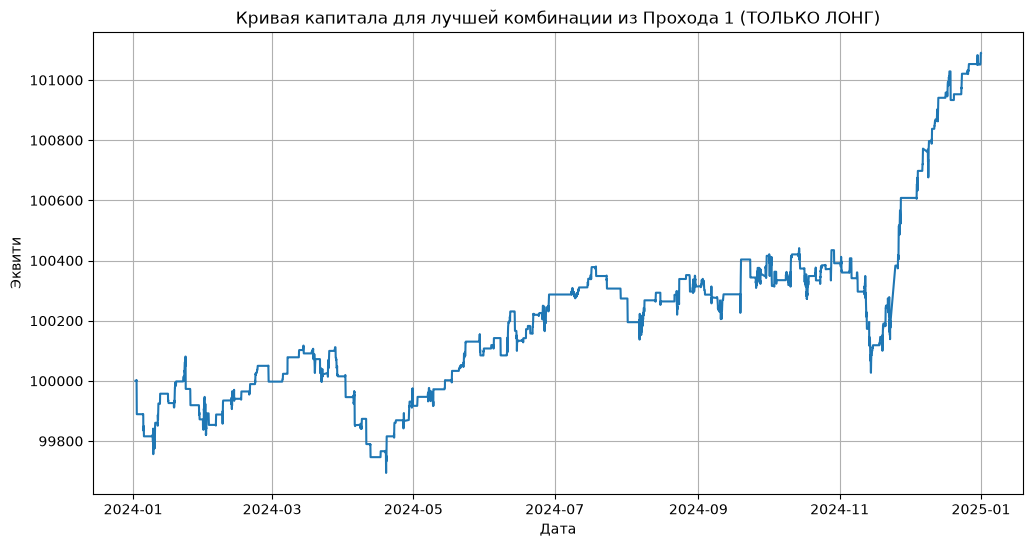

In [15]:
print('--- Кривая капитала (Equity Curve) для лучшей комбинации из Прохода 1 (ТОЛЬКО ЛОНГ) ---')

# Получаем лучшие параметры из r1
best1_params = {
    "level_method": int(best1["level_method"]),
    "buffer_atr_s": float(best1["buffer_atr_s"]),
    "sl_atr_s": float(best1["sl_atr_s"]),
    "tp_atr_s": float(best1.get("tp_atr_s", 2.0)), # Используем tp_atr_s (fallback 2.0)
    "buffer_atr_r": float(best1["buffer_atr_r"]),
    "sl_atr_r": float(best1["sl_atr_r"]),
    "tp_atr_r": float(best1.get("tp_atr_r", 2.0)), # Используем tp_atr_r (fallback 2.0)
    "long_only": bool(best1["long_only"]),
    "short_only": bool(best1["short_only"]),
}

# Запускаем backtest с лучшими параметрами из r1
ts1 = bt_train.run(**best1_params)

# Визуализируем кривую капитала
import matplotlib.pyplot as plt
import numpy as np

# Получаем Series с эквити
equity_curve_series = ts1["_equity_curve"]["Equity"]

# Фильтруем значения, где индекс не является NaT
valid_data_index = equity_curve_series.index.notna()
valid_equity_series = equity_curve_series[valid_data_index]

# Фильтруем значения, где эквити конечно (не NaN или inf)
valid_equity_series = valid_equity_series[np.isfinite(valid_equity_series.values)]

fig = plt.figure(figsize=(12, 6))
plt.plot(valid_equity_series.index, valid_equity_series.values)
plt.title('Кривая капитала для лучшей комбинации из Прохода 1 (ТОЛЬКО ЛОНГ)')
plt.xlabel('Дата')
plt.ylabel('Эквити')
plt.grid(True)
plt.show()

In [16]:
# ---------- ИТОГОВАЯ ТАБЛИЦА: МЕТОД + МНОЖИТЕЛИ + ГДЕ СТАВИТЬ ОРДЕРА ----------
# Лучший метод для ЛОНГ (S-множители из best1, метод из best_long)
m_long = int(test_params_long["level_method"])
# Лучший метод для ШОРТ (R-множители из best2, метод из best_short)
m_short = int(test_params_short["level_method"])

last = df.iloc[-1]
atr, close = last["ATR"], last["Close"]
sup = sup_col = res = res_col = None
for col in SUP_COLS[m_long]:
    v = last[col]
    if np.isfinite(v) and v <= close and (sup is None or v > sup):
        sup, sup_col = v, col
for col in RES_COLS[m_short]:
    v = last[col]
    if np.isfinite(v) and v >= close and (res is None or v < res):
        res, res_col = v, col

b_s = test_params_long["buffer_atr_s"]
s_s = test_params_long["sl_atr_s"]
t_s = test_params_long.get("tp_atr_s", 2.0)
b_r = test_params_short["buffer_atr_r"]
s_r = test_params_short["sl_atr_r"]
t_r = test_params_short.get("tp_atr_r", 2.0)

print("Лучший метод для ЛОНГ :", LEVEL_METHOD_NAMES[m_long])
print(f"  Буфер S : {b_s:.2f} x ATR | SL S: {s_s:.2f} x ATR | TP S: {t_s:.2f} x ATR")
print("Лучший метод для ШОРТ :", LEVEL_METHOD_NAMES[m_short])
print(f"  Буфер R : {b_r:.2f} x ATR | SL R: {s_r:.2f} x ATR | TP R: {t_r:.2f} x ATR")
print("\nПравило постановки ордеров (уровни пересчитываются каждый день):")
print(f"  Buy  Limit = S + {b_s:.2f} * ATR   (лонг от поддержки S, метод {LEVEL_METHOD_NAMES[m_long]})")
print(f"  Sell Limit = R - {b_r:.2f} * ATR   (шорт от сопротивления R, метод {LEVEL_METHOD_NAMES[m_short]})")
if sup is not None and res is not None:
    print(f"\nПример на последнем баре ({last.name}):")
    print(f"  ATR(14) = {atr:.5f}, Close = {close:.5f}")
    print(f"  S = {sup:.5f} ({sup_col})  -> Buy  Limit = {sup + b_s * atr:.5f}")
    print(f"  R = {res:.5f} ({res_col})  -> Sell Limit = {res - b_r * atr:.5f}")

try:
    # Сохраняем результаты отдельно для лонга и шорта
    combined = pd.concat([
        top_table(r1.rename(columns={'tp_atr_s': 'tp_atr_s', 'tp_atr_r': 'tp_atr_r'}), CONFIG).assign(Pass="long"),
        top_table(r2.rename(columns={'tp_atr_s': 'tp_atr_s', 'tp_atr_r': 'tp_atr_r'}), CONFIG).assign(Pass="short"),
        top_table(r3_long.rename(columns={'tp_atr_s': 'tp_atr_s', 'tp_atr_r': 'tp_atr_r'}), CONFIG).assign(Pass="method_long"),
        top_table(r3_short.rename(columns={'tp_atr_s': 'tp_atr_s', 'tp_atr_r': 'tp_atr_r'}), CONFIG).assign(Pass="method_short"),
    ])
    combined.to_csv("results_atr_sweep.csv", index=False)
    print("\nРезультаты сохранены: results_atr_sweep.csv")
except Exception as e:
    print("\nНе удалось сохранить CSV:", e)

Лучший метод для ЛОНГ : DeMark
  Буфер S : 0.25 x ATR | SL S: 3.00 x ATR | TP S: 1.50 x ATR
Лучший метод для ШОРТ : DeMark
  Буфер R : 0.05 x ATR | SL R: 3.00 x ATR | TP R: 1.50 x ATR

Правило постановки ордеров (уровни пересчитываются каждый день):
  Buy  Limit = S + 0.25 * ATR   (лонг от поддержки S, метод DeMark)
  Sell Limit = R - 0.05 * ATR   (шорт от сопротивления R, метод DeMark)

Результаты сохранены: results_atr_sweep.csv


## Как читать результат

1. **Проход 1** — лучшие множители лонга (`buffer_atr_s`, `sl_atr_s`, `tp_atr_s`) и метод.
2. **Проход 2** — лучшие множители шорта (`buffer_atr_r`, `sl_atr_r`, `tp_atr_r`) и метод.
3. **Проход 3a** — выбор лучшего метода для ЛОНГ при лучших S-множителях (`long_only=True`).
4. **Проход 3b** — выбор лучшего метода для ШОРТ при лучших R-множителях (`short_only=True`).
5. **Проверка на 2025** — результаты лучших комбинаций лонг и шорт отдельно на данных, не участвовавших в подборе.

⚠️ Напоминание: комиссия ~0.002%, спред не моделируется; граница дня по умолчанию —
полночь UTC (если в MT5 серверные сутки, задайте `day_offset_hours` = 2 или 3).